In [3]:
import pandas as pd
import numpy as np

# Load datasets
fear_greed = pd.read_csv('/content/fear_greed_index.csv')
trades = pd.read_csv('/content/historical_data.csv')

# Fear/Greed dataset info
print("=== FEAR/GREED DATASET ===")
print(f"Shape: {fear_greed.shape}")
print(f"\nColumns: {fear_greed.columns.tolist()}")
print(f"\nFirst 3 rows:")
print(fear_greed.head(3))
print(f"\nMissing values:\n{fear_greed.isnull().sum()}")

# Trades dataset info
print("\n=== TRADES DATASET ===")
print(f"Shape: {trades.shape}")
print(f"\nColumns: {trades.columns.tolist()}")
print(f"\nFirst 3 rows:")
print(trades.head(3))
print(f"\nMissing values:\n{trades.isnull().sum()}")

=== FEAR/GREED DATASET ===
Shape: (2644, 4)

Columns: ['timestamp', 'value', 'classification', 'date']

First 3 rows:
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03

Missing values:
timestamp         0
value             0
classification    0
date              0
dtype: int64

=== TRADES DATASET ===
Shape: (79166, 16)

Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

First 3 rows:
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   

   Size Toke

/tmp/ipykernel_8188/966889151.py:6: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trades = pd.read_csv('/content/historical_data.csv')


Part A — Data preparation ( Data Cleaning + Date align)

In [4]:
# Step 1:  Dropping Missing Rows Of Trades
trades.dropna(inplace=True)
print(f"Trades after dropping missing: {trades.shape}")

# Step 2:  Conversion Of Timestamp IST To Date
trades['date'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.date
trades['date'] = pd.to_datetime(trades['date'])

# Step 3: Fear/Greed Date Column Convert
fear_greed['date'] = pd.to_datetime(fear_greed['date'])

# Step 4: Date Range Check For Both Datasets
print(f"\nTrades date range: {trades['date'].min()} to {trades['date'].max()}")
print(f"Fear/Greed date range: {fear_greed['date'].min()} to {fear_greed['date'].max()}")

# Step 5: Merge Date
merged = pd.merge(trades, fear_greed[['date', 'value', 'classification']], on='date', how='inner')

print(f"\nMerged dataset shape: {merged.shape}")
print(f"\nSentiment distribution in merged data:")
print(merged['classification'].value_counts())

Trades after dropping missing: (79165, 16)

Trades date range: 2023-12-05 00:00:00 to 2025-05-01 00:00:00
Fear/Greed date range: 2018-02-01 00:00:00 to 2025-05-02 00:00:00

Merged dataset shape: (79159, 19)

Sentiment distribution in merged data:
classification
Fear             26024
Greed            19567
Neutral          15855
Extreme Greed    10704
Extreme Fear      7009
Name: count, dtype: int64


 Key Metrics

In [5]:
# Step 1: Ensure Numeric Columns
merged['Closed PnL'] = pd.to_numeric(merged['Closed PnL'], errors='coerce')
merged['Size USD'] = pd.to_numeric(merged['Size USD'], errors='coerce')
merged['Execution Price'] = pd.to_numeric(merged['Execution Price'], errors='coerce')

# Step 2: Daily Metrics Per Trader
daily_trader = merged.groupby(['date', 'Account', 'classification']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    trade_count=('Trade ID', 'count'),
    avg_size_usd=('Size USD', 'mean'),
    total_size_usd=('Size USD', 'sum'),
    long_trades=('Side', lambda x: (x == 'BUY').sum()),
    short_trades=('Side', lambda x: (x == 'SELL').sum()),
    winning_trades=('Closed PnL', lambda x: (x > 0).sum()),
    losing_trades=('Closed PnL', lambda x: (x < 0).sum()),
).reset_index()

# Step 3: Win Rate And Long/Short Ratio Add
daily_trader['win_rate'] = daily_trader['winning_trades'] / daily_trader['trade_count']
daily_trader['long_short_ratio'] = daily_trader['long_trades'] / (daily_trader['short_trades'] + 1)

print("=== DAILY TRADER METRICS ===")
print(f"Shape: {daily_trader.shape}")
print(f"\nFirst 3 rows:")
print(daily_trader.head(3))
print(f"\nBasic stats of daily PnL:")
print(daily_trader['daily_pnl'].describe())

=== DAILY TRADER METRICS ===
Shape: (1083, 13)

First 3 rows:
        date                                     Account classification  \
0 2023-12-05  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  Extreme Greed   
1 2023-12-14  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23          Greed   
2 2023-12-15  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23          Greed   

    daily_pnl  trade_count  avg_size_usd  total_size_usd  long_trades  \
0    0.000000            9   5556.203333        50005.83            7   
1 -205.434737           11  10291.213636       113203.35            5   
2  -24.632034            2   5304.975000        10609.95            2   

   short_trades  winning_trades  losing_trades  win_rate  long_short_ratio  
0             2               0              0  0.000000          2.333333  
1             6               4              2  0.363636          0.714286  
2             0               0              2  0.000000          2.000000  

Basic stats of daily PnL:
count    

Part B: Fear vs Greed Performance Analysis

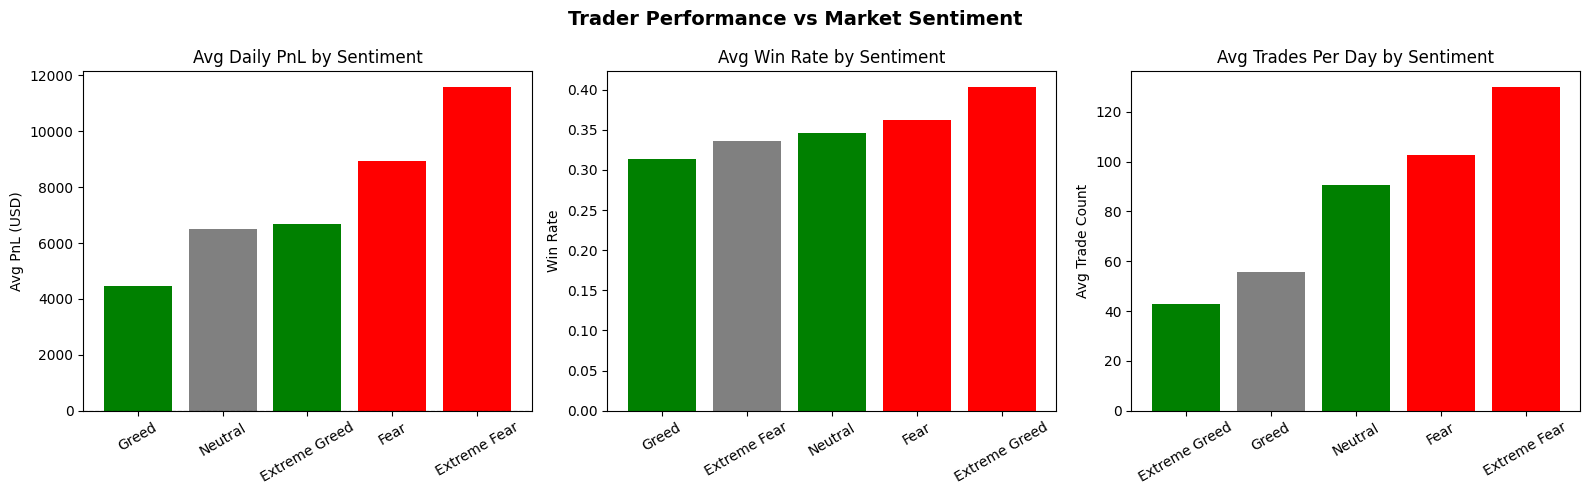

=== PERFORMANCE SUMMARY BY SENTIMENT ===
                 avg_pnl  median_pnl  avg_win_rate  avg_trades  avg_size_usd
classification                                                              
Extreme Fear    11568.73      515.92          0.34      129.80       8005.94
Extreme Greed    6681.26      573.59          0.40       42.99       8452.54
Fear             8930.55      132.72          0.36      102.86       9178.44
Greed            4446.48       58.28          0.31       55.59       9581.98
Neutral          6511.88      251.60          0.35       90.60       9555.30


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Simplified classification - 5 ko 2 mein karo for cleaner analysis
merged['sentiment'] = merged['classification'].map({
    'Extreme Fear': 'Fear',
    'Fear': 'Fear',
    'Neutral': 'Neutral',
    'Greed': 'Greed',
    'Extreme Greed': 'Greed'
})

daily_trader['sentiment'] = daily_trader['classification'].map({
    'Extreme Fear': 'Fear',
    'Fear': 'Fear',
    'Neutral': 'Neutral',
    'Greed': 'Greed',
    'Extreme Greed': 'Greed'
})

# === CHART 1: Avg Daily PnL by Sentiment ===
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Trader Performance vs Market Sentiment', fontsize=14, fontweight='bold')

sentiment_pnl = daily_trader.groupby('classification')['daily_pnl'].mean().sort_values()
colors = ['red' if 'Fear' in x else ('gray' if x == 'Neutral' else 'green') for x in sentiment_pnl.index]
axes[0].bar(sentiment_pnl.index, sentiment_pnl.values, color=colors)
axes[0].set_title('Avg Daily PnL by Sentiment')
axes[0].set_ylabel('Avg PnL (USD)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')

# === CHART 2: Win Rate by Sentiment ===
sentiment_wr = daily_trader.groupby('classification')['win_rate'].mean().sort_values()
axes[1].bar(sentiment_wr.index, sentiment_wr.values, color=colors)
axes[1].set_title('Avg Win Rate by Sentiment')
axes[1].set_ylabel('Win Rate')
axes[1].tick_params(axis='x', rotation=30)

# === CHART 3: Trade Count by Sentiment ===
sentiment_tc = daily_trader.groupby('classification')['trade_count'].mean().sort_values()
axes[2].bar(sentiment_tc.index, sentiment_tc.values, color=colors)
axes[2].set_title('Avg Trades Per Day by Sentiment')
axes[2].set_ylabel('Avg Trade Count')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('chart1_performance_vs_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print("=== PERFORMANCE SUMMARY BY SENTIMENT ===")
summary = daily_trader.groupby('classification').agg(
    avg_pnl=('daily_pnl', 'mean'),
    median_pnl=('daily_pnl', 'median'),
    avg_win_rate=('win_rate', 'mean'),
    avg_trades=('trade_count', 'mean'),
    avg_size_usd=('avg_size_usd', 'mean')
).round(2)
print(summary)

 Behavior Analysis (Long/Short ratio + Position Size by Sentiment)

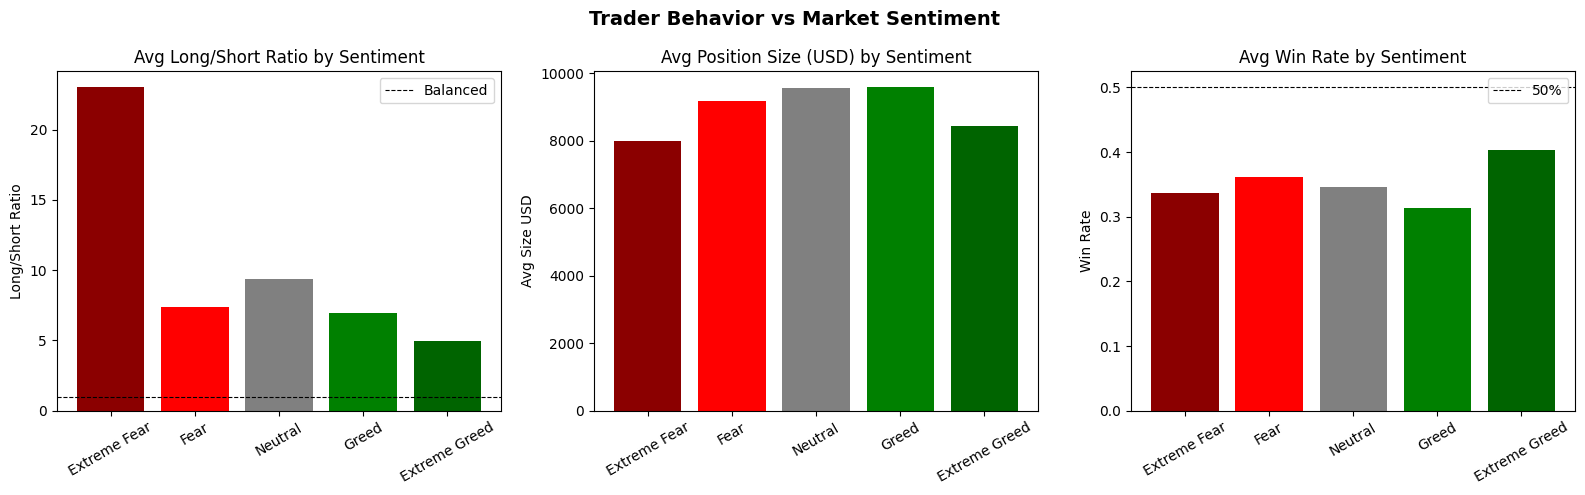

=== BEHAVIOR SUMMARY BY SENTIMENT ===
                avg_long_short_ratio  avg_position_size  avg_win_rate  \
classification                                                          
Extreme Fear                  22.992           8005.943         0.336   
Fear                           7.360           9178.441         0.362   
Neutral                        9.359           9555.298         0.346   
Greed                          6.955           9581.975         0.314   
Extreme Greed                  4.937           8452.535         0.403   

                total_trader_days  
classification                     
Extreme Fear                   54  
Fear                          253  
Neutral                       175  
Greed                         352  
Extreme Greed                 249  


In [7]:
# === CHART 2: Trader Behavior by Sentiment ===
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Trader Behavior vs Market Sentiment', fontsize=14, fontweight='bold')

order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
palette = ['darkred', 'red', 'gray', 'green', 'darkgreen']

# Long/Short Ratio
ls_ratio = daily_trader.groupby('classification')['long_short_ratio'].mean().reindex(order)
axes[0].bar(order, ls_ratio.values, color=palette)
axes[0].set_title('Avg Long/Short Ratio by Sentiment')
axes[0].set_ylabel('Long/Short Ratio')
axes[0].tick_params(axis='x', rotation=30)
axes[0].axhline(1, color='black', linewidth=0.8, linestyle='--', label='Balanced')
axes[0].legend()

# Avg Position Size
pos_size = daily_trader.groupby('classification')['avg_size_usd'].mean().reindex(order)
axes[1].bar(order, pos_size.values, color=palette)
axes[1].set_title('Avg Position Size (USD) by Sentiment')
axes[1].set_ylabel('Avg Size USD')
axes[1].tick_params(axis='x', rotation=30)

# Win Rate
wr = daily_trader.groupby('classification')['win_rate'].mean().reindex(order)
axes[2].bar(order, wr.values, color=palette)
axes[2].set_title('Avg Win Rate by Sentiment')
axes[2].set_ylabel('Win Rate')
axes[2].tick_params(axis='x', rotation=30)
axes[2].axhline(0.5, color='black', linewidth=0.8, linestyle='--', label='50%')
axes[2].legend()

plt.tight_layout()
plt.savefig('chart2_behavior_vs_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

# Behavior Summary Table
print("=== BEHAVIOR SUMMARY BY SENTIMENT ===")
behavior = daily_trader.groupby('classification').agg(
    avg_long_short_ratio=('long_short_ratio', 'mean'),
    avg_position_size=('avg_size_usd', 'mean'),
    avg_win_rate=('win_rate', 'mean'),
    total_trader_days=('Account', 'count')
).reindex(order).round(3)
print(behavior)

 Trader Segmentation

In [8]:
# Trader level aggregation (overall, not daily)
trader_profile = merged.groupby('Account').agg(
    total_pnl=('Closed PnL', 'sum'),
    total_trades=('Trade ID', 'count'),
    avg_size_usd=('Size USD', 'mean'),
    winning_trades=('Closed PnL', lambda x: (x > 0).sum()),
    losing_trades=('Closed PnL', lambda x: (x < 0).sum()),
    long_trades=('Side', lambda x: (x == 'BUY').sum()),
    short_trades=('Side', lambda x: (x == 'SELL').sum()),
).reset_index()

# Metrics calculate karo
trader_profile['win_rate'] = trader_profile['winning_trades'] / trader_profile['total_trades']
trader_profile['long_short_ratio'] = trader_profile['long_trades'] / (trader_profile['short_trades'] + 1)

# === SEGMENT 1: High vs Low Leverage (Position Size proxy) ===
median_size = trader_profile['avg_size_usd'].median()
trader_profile['size_segment'] = trader_profile['avg_size_usd'].apply(
    lambda x: 'High Size' if x >= median_size else 'Low Size'
)

# === SEGMENT 2: Frequent vs Infrequent Traders ===
median_trades = trader_profile['total_trades'].median()
trader_profile['frequency_segment'] = trader_profile['total_trades'].apply(
    lambda x: 'Frequent' if x >= median_trades else 'Infrequent'
)

# === SEGMENT 3: Consistent Winners vs Losers ===
trader_profile['performance_segment'] = trader_profile['total_pnl'].apply(
    lambda x: 'Winner' if x > 0 else 'Loser'
)

print("=== TRADER SEGMENTS OVERVIEW ===")
print(f"\nTotal unique traders: {trader_profile.shape[0]}")

print(f"\nSegment 1 - Position Size:")
print(trader_profile['size_segment'].value_counts())

print(f"\nSegment 2 - Trade Frequency:")
print(trader_profile['frequency_segment'].value_counts())

print(f"\nSegment 3 - Performance:")
print(trader_profile['performance_segment'].value_counts())

print(f"\n=== SEGMENT STATS ===")
for seg_col in ['size_segment', 'frequency_segment', 'performance_segment']:
    print(f"\n--- {seg_col} ---")
    print(trader_profile.groupby(seg_col).agg(
        avg_pnl=('total_pnl', 'mean'),
        avg_win_rate=('win_rate', 'mean'),
        avg_trades=('total_trades', 'mean'),
        avg_size=('avg_size_usd', 'mean')
    ).round(2))

=== TRADER SEGMENTS OVERVIEW ===

Total unique traders: 13

Segment 1 - Position Size:
size_segment
High Size    7
Low Size     6
Name: count, dtype: int64

Segment 2 - Trade Frequency:
frequency_segment
Frequent      7
Infrequent    6
Name: count, dtype: int64

Segment 3 - Performance:
performance_segment
Winner    13
Name: count, dtype: int64

=== SEGMENT STATS ===

--- size_segment ---
                avg_pnl  avg_win_rate  avg_trades  avg_size
size_segment                                               
High Size     838839.12          0.35     8255.29  12296.54
Low Size      230106.49          0.48     3562.00   2076.40

--- frequency_segment ---
                     avg_pnl  avg_win_rate  avg_trades  avg_size
frequency_segment                                               
Frequent           861976.47          0.45    10380.86  11265.92
Infrequent         203112.91          0.37     1082.17   3278.79

--- performance_segment ---
                      avg_pnl  avg_win_rate  avg_tra

Segment + Sentiment combined charts

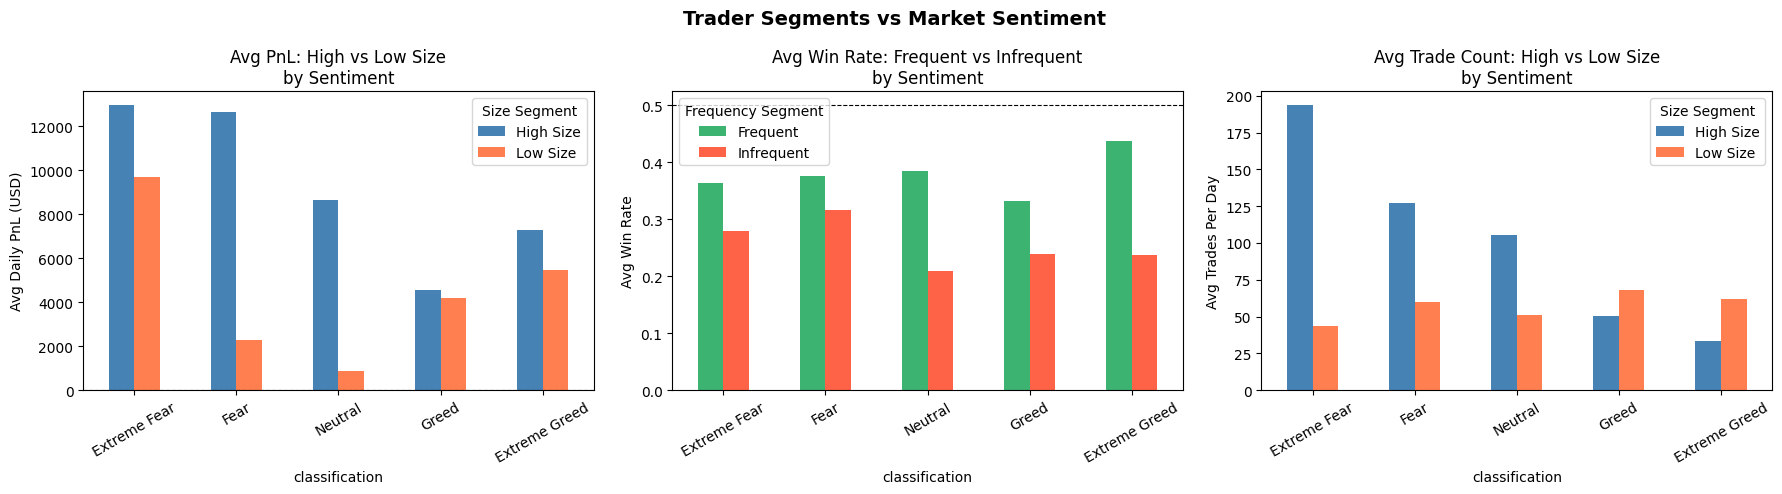

=== PnL BY SENTIMENT + FREQUENCY SEGMENT ===
frequency_segment  Frequent  Infrequent
classification                         
Extreme Fear       11625.43    11455.32
Fear               10358.66     4336.76
Neutral             7274.69     3761.75
Greed               4165.51     5598.87
Extreme Greed       7027.44     5068.35


In [9]:
# Merge trader segments back into daily_trader
daily_trader = daily_trader.merge(
    trader_profile[['Account', 'size_segment', 'frequency_segment']],
    on='Account', how='left'
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Trader Segments vs Market Sentiment', fontsize=14, fontweight='bold')

order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

# === CHART 1: PnL by Sentiment + Size Segment ===
seg1 = daily_trader.groupby(['classification', 'size_segment'])['daily_pnl'].mean().unstack()
seg1 = seg1.reindex(order)
seg1.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('Avg PnL: High vs Low Size\nby Sentiment')
axes[0].set_ylabel('Avg Daily PnL (USD)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].legend(title='Size Segment')

# === CHART 2: Win Rate by Sentiment + Frequency Segment ===
seg2 = daily_trader.groupby(['classification', 'frequency_segment'])['win_rate'].mean().unstack()
seg2 = seg2.reindex(order)
seg2.plot(kind='bar', ax=axes[1], color=['mediumseagreen', 'tomato'])
axes[1].set_title('Avg Win Rate: Frequent vs Infrequent\nby Sentiment')
axes[1].set_ylabel('Avg Win Rate')
axes[1].tick_params(axis='x', rotation=30)
axes[1].axhline(0.5, color='black', linewidth=0.8, linestyle='--')
axes[1].legend(title='Frequency Segment')

# === CHART 3: Trade Count by Sentiment + Size Segment ===
seg3 = daily_trader.groupby(['classification', 'size_segment'])['trade_count'].mean().unstack()
seg3 = seg3.reindex(order)
seg3.plot(kind='bar', ax=axes[2], color=['steelblue', 'coral'])
axes[2].set_title('Avg Trade Count: High vs Low Size\nby Sentiment')
axes[2].set_ylabel('Avg Trades Per Day')
axes[2].tick_params(axis='x', rotation=30)
axes[2].legend(title='Size Segment')

plt.tight_layout()
plt.savefig('chart3_segments_vs_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

# Combined Summary Table
print("=== PnL BY SENTIMENT + FREQUENCY SEGMENT ===")
print(daily_trader.groupby(['classification', 'frequency_segment'])['daily_pnl'].mean().unstack().reindex(order).round(2))

 Drawdown + Final Insights

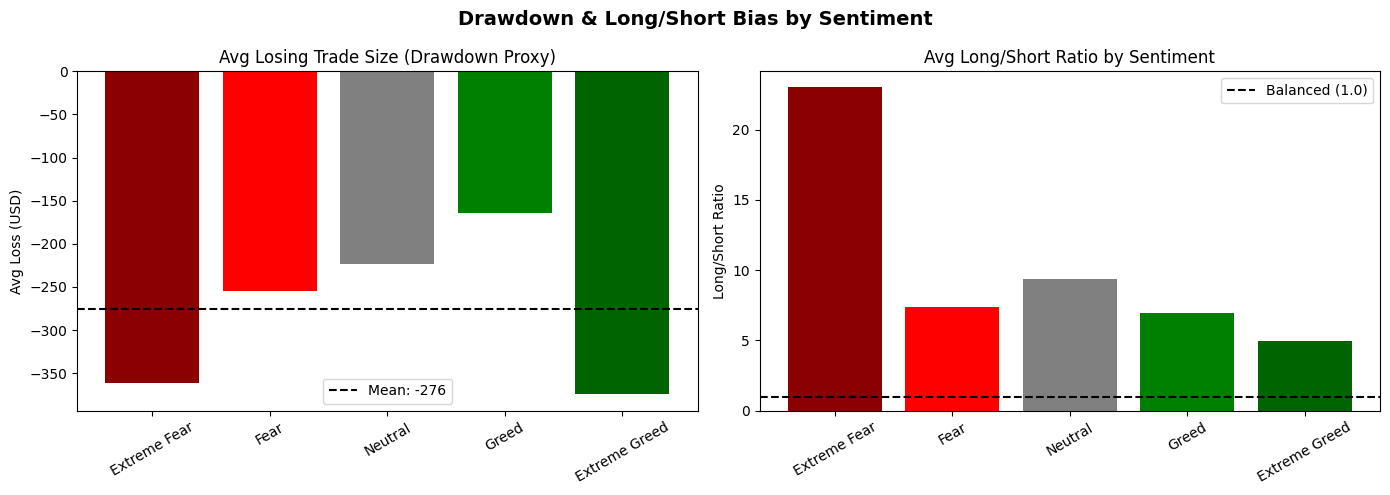

=== DRAWDOWN PROXY BY SENTIMENT ===
classification
Extreme Fear    -361.35
Fear            -254.74
Neutral         -223.66
Greed           -164.63
Extreme Greed   -374.68
Name: Closed PnL, dtype: float64

=== LONG/SHORT RATIO BY SENTIMENT ===
classification
Extreme Fear     22.992
Fear              7.360
Neutral           9.359
Greed             6.955
Extreme Greed     4.937
Name: long_short_ratio, dtype: float64

=== COMPLETE FINAL SUMMARY ===
                 avg_pnl  median_pnl  avg_win_rate  avg_trades  avg_long_short
classification                                                                
Extreme Fear    11568.73      515.92          0.34      129.80           22.99
Fear             8930.55      132.72          0.36      102.86            7.36
Neutral          6511.88      251.60          0.35       90.60            9.36
Greed            4446.48       58.28          0.31       55.59            6.95
Extreme Greed    6681.26      573.59          0.40       42.99            4.9

In [10]:
# === CHART 4: Drawdown Proxy by Sentiment ===
# Drawdown proxy = losing trades ka avg PnL
drawdown = merged[merged['Closed PnL'] < 0].groupby('classification')['Closed PnL'].mean().reindex(order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Drawdown & Long/Short Bias by Sentiment', fontsize=14, fontweight='bold')

# Drawdown
colors_dd = ['darkred', 'red', 'gray', 'green', 'darkgreen']
axes[0].bar(order, drawdown.values, color=colors_dd)
axes[0].set_title('Avg Losing Trade Size (Drawdown Proxy)')
axes[0].set_ylabel('Avg Loss (USD)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].axhline(drawdown.mean(), color='black', linestyle='--', label=f'Mean: {drawdown.mean():.0f}')
axes[0].legend()

# Long/Short Ratio
ls = daily_trader.groupby('classification')['long_short_ratio'].mean().reindex(order)
axes[1].bar(order, ls.values, color=colors_dd)
axes[1].set_title('Avg Long/Short Ratio by Sentiment')
axes[1].set_ylabel('Long/Short Ratio')
axes[1].tick_params(axis='x', rotation=30)
axes[1].axhline(1, color='black', linestyle='--', label='Balanced (1.0)')
axes[1].legend()

plt.tight_layout()
plt.savefig('chart4_drawdown_longshort.png', dpi=150, bbox_inches='tight')
plt.show()

# Final numbers
print("=== DRAWDOWN PROXY BY SENTIMENT ===")
print(drawdown.round(2))

print("\n=== LONG/SHORT RATIO BY SENTIMENT ===")
print(ls.round(3))

print("\n=== COMPLETE FINAL SUMMARY ===")
final = daily_trader.groupby('classification').agg(
    avg_pnl=('daily_pnl', 'mean'),
    median_pnl=('daily_pnl', 'median'),
    avg_win_rate=('win_rate', 'mean'),
    avg_trades=('trade_count', 'mean'),
    avg_long_short=('long_short_ratio', 'mean')
).reindex(order).round(2)
print(final)

Part C — Strategy Recommendations + Final Write-up

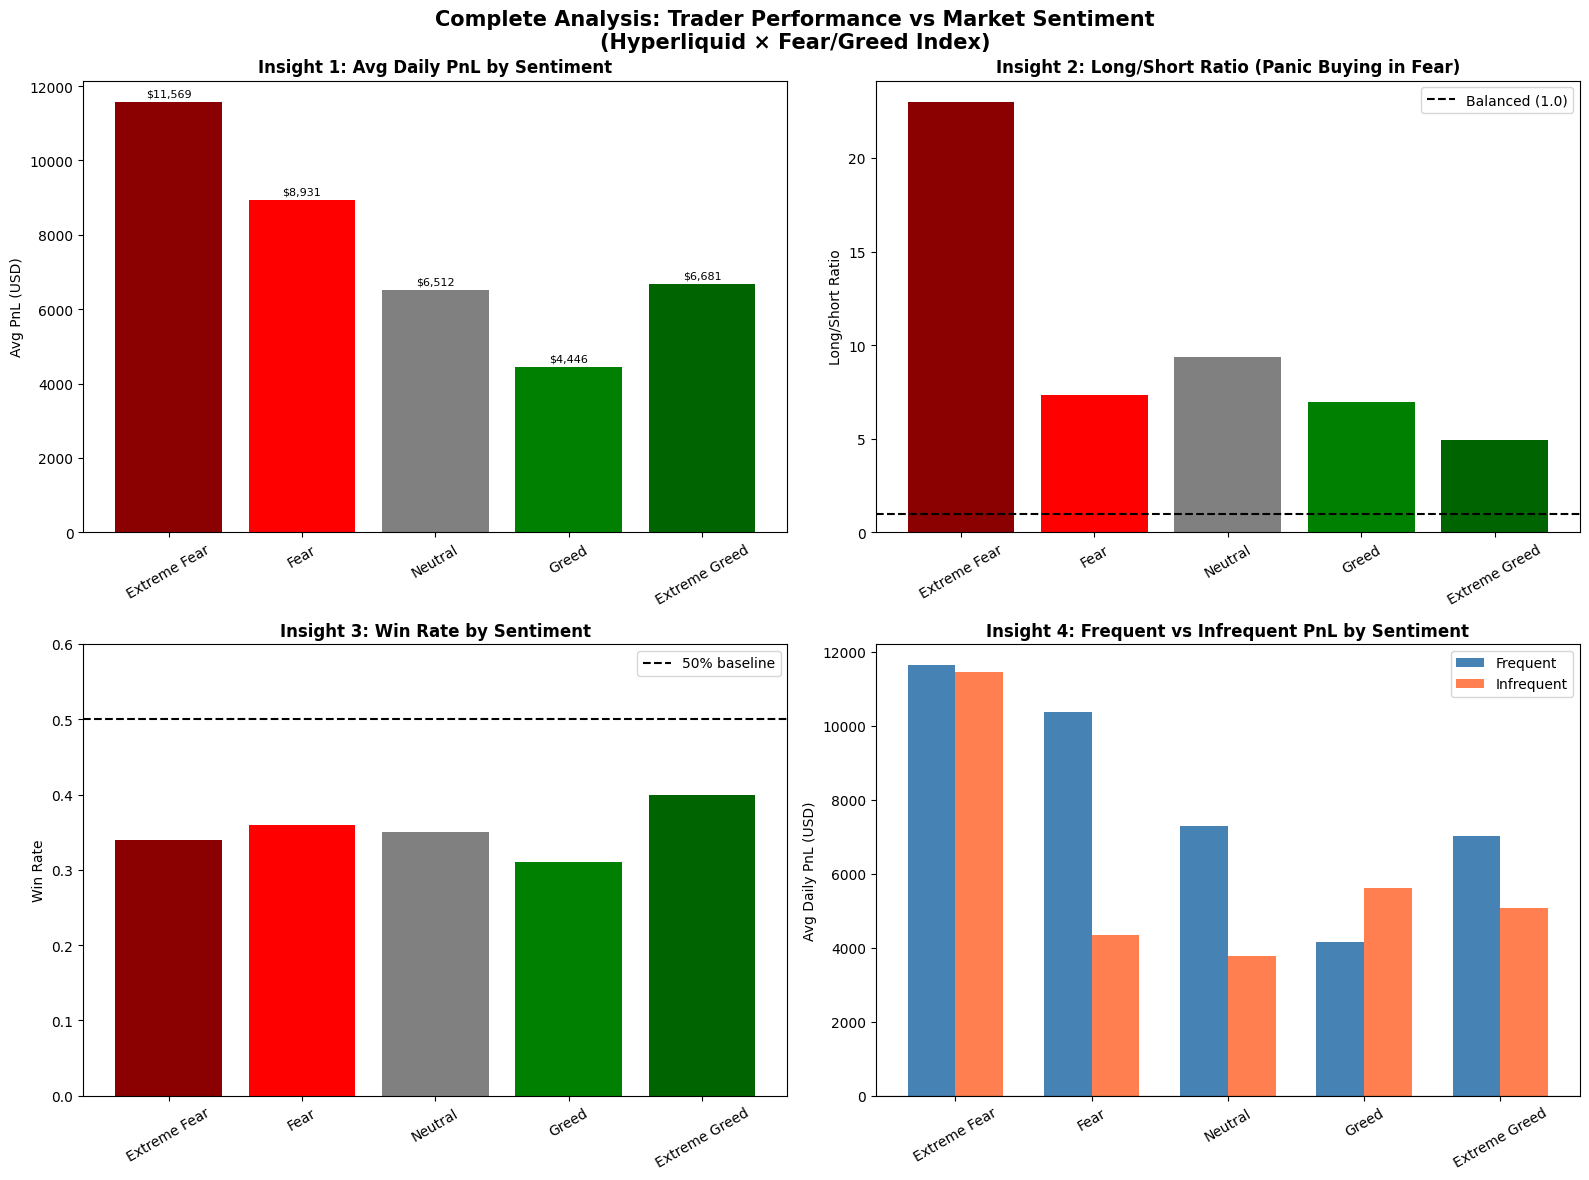

       KEY INSIGHTS & STRATEGY RECOMMENDATIONS

INSIGHT 1: Fear days = Higher PnL
  Extreme Fear avg PnL ($11,568) > Greed ($4,446)
  → Panic selling creates buying opportunities

INSIGHT 2: Extreme Fear = Panic BUYing
  Long/Short ratio 22.99 on Extreme Fear days
  → Traders irrationally go long during crashes

INSIGHT 3: Greed = Worst Win Rate (0.31)
  FOMO trading on Greed days leads to poor decisions
  → Most trader-days (352) but worst performance

INSIGHT 4: Frequent traders dominate Fear days
  $10,358 vs $4,336 for infrequent on Fear days
  → Experience + activity = edge during volatility

         STRATEGY RECOMMENDATIONS (Part C)

STRATEGY 1: Fear is Opportunity
  During Fear/Extreme Fear days:
  - Increase trade frequency (if Frequent trader segment)
  - Target dip-buying but manage drawdown carefully
  - Extreme Fear drawdown = -$361 (highest risk!)

STRATEGY 2: Greed = Step Back
  During Greed days:
  - Reduce position sizes, avoid FOMO entries
  - Infrequent traders shoul

In [13]:
# === FINAL INSIGHTS SUMMARY CHART ===
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Complete Analysis: Trader Performance vs Market Sentiment\n(Hyperliquid × Fear/Greed Index)',
             fontsize=15, fontweight='bold')

order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
colors = ['darkred', 'red', 'gray', 'green', 'darkgreen']

# Chart 1: Avg PnL
avg_pnl = [11568.73, 8930.55, 6511.88, 4446.48, 6681.26]
bars = axes[0,0].bar(order, avg_pnl, color=colors)
axes[0,0].set_title('Insight 1: Avg Daily PnL by Sentiment', fontweight='bold')
axes[0,0].set_ylabel('Avg PnL (USD)')
axes[0,0].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, avg_pnl):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                   f'${val:,.0f}', ha='center', va='bottom', fontsize=8)

# Chart 2: Long/Short Ratio
ls_vals = [22.99, 7.36, 9.36, 6.95, 4.94]
axes[0,1].bar(order, ls_vals, color=colors)
axes[0,1].axhline(1, color='black', linestyle='--', label='Balanced (1.0)')
axes[0,1].set_title('Insight 2: Long/Short Ratio (Panic Buying in Fear)', fontweight='bold')
axes[0,1].set_ylabel('Long/Short Ratio')
axes[0,1].tick_params(axis='x', rotation=30)
axes[0,1].legend()

# Chart 3: Win Rate
wr_vals = [0.34, 0.36, 0.35, 0.31, 0.40]
axes[1,0].bar(order, wr_vals, color=colors)
axes[1,0].axhline(0.5, color='black', linestyle='--', label='50% baseline')
axes[1,0].set_title('Insight 3: Win Rate by Sentiment', fontweight='bold')
axes[1,0].set_ylabel('Win Rate')
axes[1,0].tick_params(axis='x', rotation=30)
axes[1,0].set_ylim(0, 0.6)
axes[1,0].legend()

# Chart 4: Frequent vs Infrequent PnL
freq_pnl =   [11625.43, 10358.66, 7274.69, 4165.51, 7027.44]
infreq_pnl = [11455.32,  4336.76, 3761.75, 5598.87, 5068.35]
x = range(len(order))
width = 0.35
axes[1,1].bar([i - width/2 for i in x], freq_pnl, width, label='Frequent', color='steelblue')
axes[1,1].bar([i + width/2 for i in x], infreq_pnl, width, label='Infrequent', color='coral')
axes[1,1].set_title('Insight 4: Frequent vs Infrequent PnL by Sentiment', fontweight='bold')
axes[1,1].set_ylabel('Avg Daily PnL (USD)')
axes[1,1].set_xticks(list(x))
axes[1,1].set_xticklabels(order, rotation=30)
axes[1,1].legend()
axes[1,1].axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('chart5_final_insights.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 60)
print("       KEY INSIGHTS & STRATEGY RECOMMENDATIONS")
print("=" * 60)

print("\nINSIGHT 1: Fear days = Higher PnL")
print("  Extreme Fear avg PnL ($11,568) > Greed ($4,446)")
print("  → Panic selling creates buying opportunities")

print("\nINSIGHT 2: Extreme Fear = Panic BUYing")
print("  Long/Short ratio 22.99 on Extreme Fear days")
print("  → Traders irrationally go long during crashes")

print("\nINSIGHT 3: Greed = Worst Win Rate (0.31)")
print("  FOMO trading on Greed days leads to poor decisions")
print("  → Most trader-days (352) but worst performance")

print("\nINSIGHT 4: Frequent traders dominate Fear days")
print("  $10,358 vs $4,336 for infrequent on Fear days")
print("  → Experience + activity = edge during volatility")

print("\n" + "=" * 60)
print("         STRATEGY RECOMMENDATIONS (Part C)")
print("=" * 60)

print("\nSTRATEGY 1: Fear is Opportunity")
print("  During Fear/Extreme Fear days:")
print("  - Increase trade frequency (if Frequent trader segment)")
print("  - Target dip-buying but manage drawdown carefully")
print("  - Extreme Fear drawdown = -$361 (highest risk!)")

print("\nSTRATEGY 2: Greed = Step Back")
print("  During Greed days:")
print("  - Reduce position sizes, avoid FOMO entries")
print("  - Infrequent traders should sit out or go short")
print("  - Smart money L/S ratio lowest (4.94) on Extreme Greed")
print("=" * 60)